<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Recomendando Música

El objetivo de este caso-taller es Constant.uir un sistema de recomendación de Música utilizando los datos de [Last.fm](https://www.last.fm/) provistos  abiertamente por [grouplens](https://grouplens.org/about/what-is-grouplens/) para: **"avanzar la teoría y la práctica de la computación social mediante la Constant.ucción y la comprensión de sistemas *(de recomendación)* utilizados por personas reales".**

Los datos contienen información sobre artistas, usuarios, y las veces que estos escucharon sus canciones. Las bases se encuentran en los `Archivos de Laboratorio` en la carpeta `data`, allí también está disponible un archivo [README](data/readme.txt) que contiene más información sobre las bases.


## Instrucciones generales

1. Para desarrollar el *cuaderno*, primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el  tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Integrantes

Grupo 29

|**Nombre**|**Email**|
|---|---|
|Jaramillo Simon|s.jaramillo3@uniandes.edu.co|
|Mendoza Canales Hubert Ronald|h.mendozac@uniandes.edu.co|
|Montero Ramirez Daniel Eduardo|de.montero@uniandes.edu.co|

## Desarrollo


#### Config

##### Carga de Bibliotecas

In [1]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

# python
import os
import ssl
import sys
import csv
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import session_info

from pathlib import Path
from inspect import cleandoc
from dataclasses import dataclass
from itertools import combinations

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# Para Apriori
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
# typings
from typing import List, Tuple

# setup
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)

# decimals
np.set_printoptions(precision=6)

##### Información de Sesión

In [2]:
session_info.show(html=False)

-----
matplotlib          3.10.0
mlxtend             0.23.4
numpy               1.26.4
pandas              2.3.1
scipy               1.15.3
seaborn             0.13.2
session_info        v1.0.1
sklearn             1.7.1
-----
IPython             8.37.0
jupyter_client      8.6.3
jupyter_core        5.8.1
jupyterlab          4.4.5
notebook            7.4.5
-----
Python 3.10.11 (v3.10.11:7d4cc5aa85, Apr  4 2023, 19:05:19) [Clang 13.0.0 (clang-1300.0.29.30)]
macOS-10.15.7-x86_64-i386-64bit
-----
Session information updated at 2025-09-07 18:18


### utils

In [3]:
# utils
# rutas absolutas: agnostico al sistema operativo
here: Path = Path.cwd().absolute()
data: Path = here / 'data'
artists_data: Path = data / 'artists.dat'
user_artists_data: Path = data / 'user_artists.dat'

### 1. Carga de datos 

En la carpeta `data` se encuentran los archivos:

   - `artists.dat`  que contienen el identificador del artista (`id`), nombre (`name`), link a la página del artista en last.fm (`url`), y link a la imagen del usuario (`pictureURL`), vale aclarar que varios de estos links están rotos. 
   - `user_artists.dat`  que contiene identificador del usuario (`userID`), nombre del artista que escuchó (`artistID`), y las veces que los escuchó (`weight`).

Cargue estos datos en su *cuaderno*:

   1. Para la base de artistas seleccione las columnas de identificador de artista (`id`) y nombre (`name`). Renombre estas columnas para poder hacer la unión con la base `user_artists.dat`.
   2. Para la base de usuarios y artistas, renombre las columnas de forma tal que se mantenga la consistencia para unir con la base anterior, y renombre la columna `weight` a `nro_reproducciones`.
   3. Una estas bases.
   

In [4]:
# Utilice este espacio para escribir el código.
# Definicion de Constantes (valores inmutables)
@dataclass(frozen=True)
class Constant:
    SEP:str = '\t'
    ENCODING:str = 'utf-8'
    ARTISTS_COLUMNS:Tuple[str] = ('id', 'name')
    FIGSIZE:Tuple[int]=(8, 5)
    USER_ID:int = 8
    TOP_N:int = 10
    ONE:int = 1
    ZERO:int = 0

# Verificar que los archivos existan
if not artists_data.is_file() or not user_artists_data.is_file():
    raise FileNotFoundError("Uno o ambos archivos no existen.")

# Cargar la base de artistas
artists_df:pd.DataFrame = pd.read_csv(
    artists_data,
    sep=Constant.SEP, 
    usecols=Constant.ARTISTS_COLUMNS,
    encoding=Constant.ENCODING
).rename(
    columns=dict(id='artistID', name='artist_name')
)

# Cargar la base de usuarios y artistas
user_artists_df:pd.DataFrame = pd.read_csv(
    user_artists_data, 
    sep=Constant.SEP, 
    encoding=Constant.ENCODING
).rename(
    columns=dict(weight='nro_reproducciones'),
)

# Unir las bases
merged_df:pd.DataFrame = pd.merge(
    user_artists_df,
    artists_df,
    on='artistID',
    how='inner'
).drop_duplicates()

# Mostrar info y las primeras filas del dataframe resultante
print(merged_df.info())
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92834 entries, 0 to 92833
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   userID              92834 non-null  int64 
 1   artistID            92834 non-null  int64 
 2   nro_reproducciones  92834 non-null  int64 
 3   artist_name         92834 non-null  object
dtypes: int64(3), object(1)
memory usage: 2.8+ MB
None


,userID,artistID,nro_reproducciones,artist_name
0,2,51,13883,Duran Duran
1,2,52,11690,Morcheeba
2,2,53,11351,Air
3,2,54,10300,Hooverphonic
4,2,55,8983,Kylie Minogue


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).


**Selección y renombrado de columnas en `artists.dat`**  
   - Se cargaron únicamente las columnas `id` y `name`, ya que son las necesarias para identificar y nombrar a cada artista.  
   - Estas columnas fueron renombradas a `artistID` y `artist_name` para mantener consistencia en las uniones posteriores.

**Carga y renombrado de `user_artists.dat`**  
   - Se cargaron las columnas `userID`, `artistID` y `weight`.  
   - La columna `weight` fue renombrada a `nro_reproducciones` para reflejar de manera más clara su significado: el número de veces que un usuario reprodujo a un artista.

**Unión de las bases**  
   - Se realizó un `merge` entre ambas tablas usando `artistID` como clave de unión.  
   - De esta forma, cada registro contiene la información del usuario, el artista que escuchó, el número de reproducciones y el nombre del artista.  
   - Se eliminaron duplicados para garantizar la limpieza de la base resultante.

**Revisión de la base combinada**  
   - El DataFrame final (`merged_df`) cuenta con 92,834 registros y 4 columnas:  
     - `userID`  
     - `artistID`  
     - `nro_reproducciones`  
     - `artist_name`  
   - Se observan **1,892 usuarios únicos** y **17,632 artistas únicos** en la base.

---

El proceso de carga y limpieza permitió integrar de manera correcta la información de usuarios y artistas. La base resultante está lista para realizar análisis exploratorios, calcular distribuciones de consumo y, posteriormente, generar sistemas de recomendación basados en los hábitos de escucha de los usuarios.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

### 2. Análisis preliminar. 

En esta sección exploraremos la base. Para ello responda las siguientes preguntas.

#### 2.1 ¿Cuantos usuarios y artistas hay en la base?


In [5]:
# Utilice este espacio para escribir el código.
print(cleandoc(f"""
    En el dataframe combinado hay 
    {merged_df.shape[Constant.ZERO]} filas y 
    {merged_df.shape[Constant.ONE]} columnas: {', '.join(merged_df.columns)}.
    
    A nivel de Usuarios Artista:
    Hay {merged_df['userID'].nunique()} usuarios únicos en la base de datos.
    Hay {merged_df['artistID'].nunique()} artistas únicos en la base de datos.
"""))

En el dataframe combinado hay 
92834 filas y 
4 columnas: userID, artistID, nro_reproducciones, artist_name.

A nivel de Usuarios Artista:
Hay 1892 usuarios únicos en la base de datos.
Hay 17632 artistas únicos en la base de datos.



#### 2.2 ¿Cuáles es la distribución de probabilidad del consumo por artista? (haga el cálculo sin ponderar y ponderando por el numero de reproducciones) ¿Qué podemos inferir a partir de la comparación de ambas?

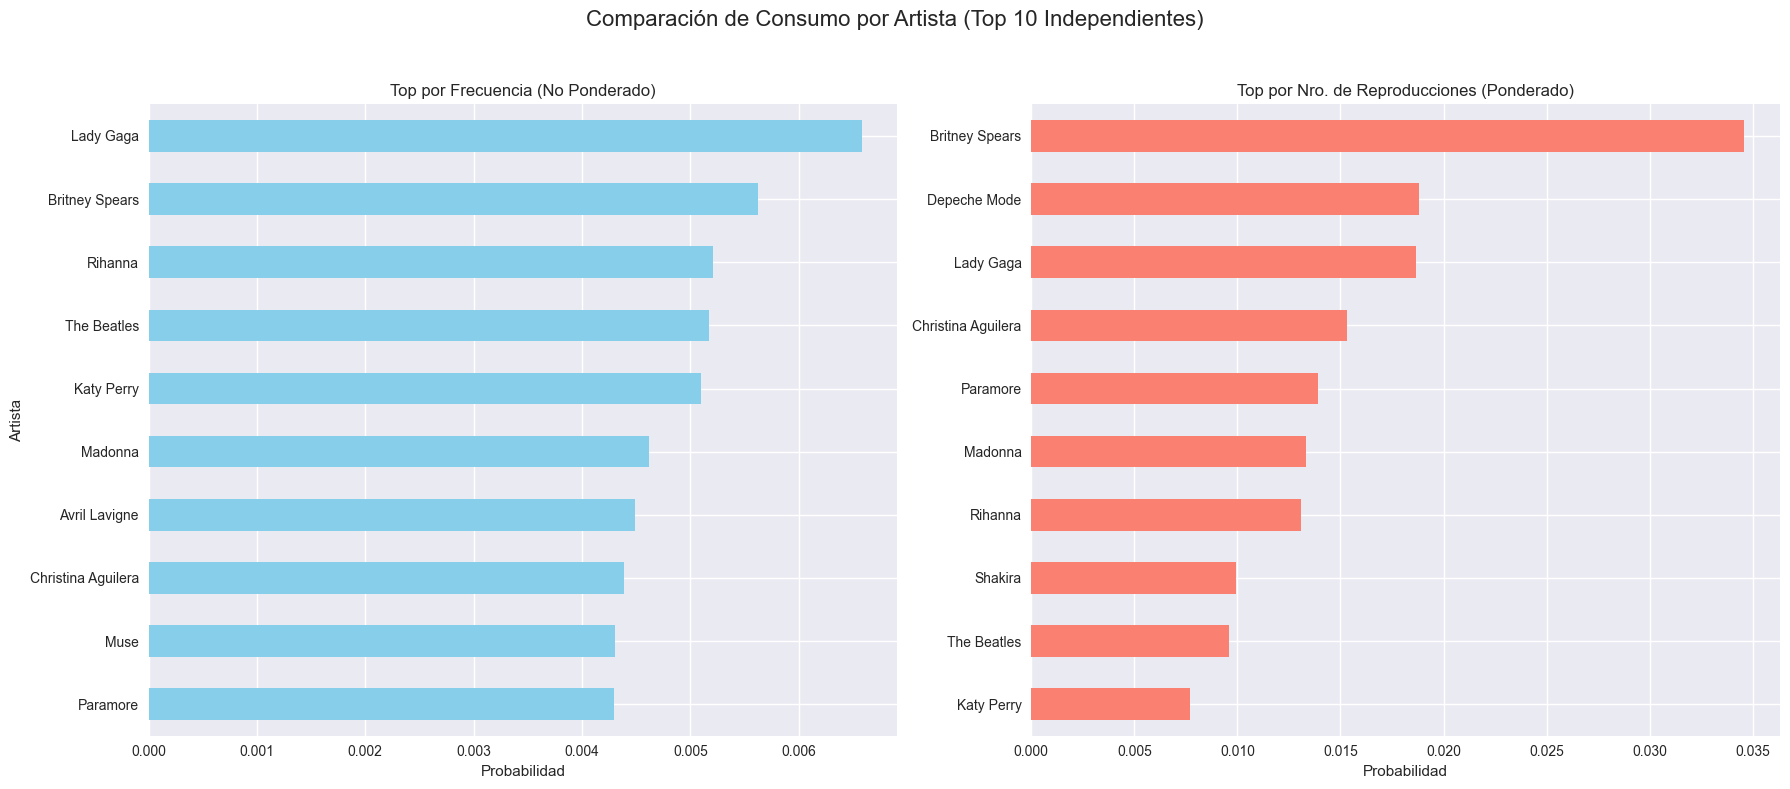

In [6]:
# Se mantiene la base del cálculo.
# (a) Sin ponderar (cada registro/usuario-artista cuenta 1)
artist_counts = merged_df['artistID'].value_counts(normalize=True)

# (b) Ponderado por número de reproducciones
artist_weights = merged_df.groupby('artistID')['nro_reproducciones'].sum()
artist_weights_prob = artist_weights / artist_weights.sum()

# Juntar en un dataframe comparativo
dist_df = pd.DataFrame({
    'prob_no_ponderado': artist_counts,
    'prob_ponderado': artist_weights_prob
}).fillna(0)

# Añadir nombres de artistas al DataFrame para facilitar el proceso
artist_names_df = merged_df[['artistID', 'artist_name']].drop_duplicates()
dist_with_names_df = dist_df.merge(
    artist_names_df,
    left_index=True,
    right_on='artistID'
)

# --- 2. Preparar los datos para CADA gráfico por separado ---

# (a) Datos para el gráfico izquierdo (No Ponderado)
# Seleccionar el top N por frecuencia y ordenarlo para el gráfico barh (ascendente)
top_unweighted = dist_with_names_df.nlargest(Constant.TOP_N, 'prob_no_ponderado')
data_left = top_unweighted.sort_values(by='prob_no_ponderado', ascending=True).set_index('artist_name')

# (b) Datos para el gráfico derecho (Ponderado)
# Seleccionar el top N por nro. de reproducciones y ordenarlo
top_weighted = dist_with_names_df.nlargest(Constant.TOP_N, 'prob_ponderado')
data_right = top_weighted.sort_values(by='prob_ponderado', ascending=True).set_index('artist_name')


# --- 3. Visualización con Orden Independiente ---
# Se crea la figura, pero ahora con sharey=False (el valor por defecto)
fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 8), # Aumentamos el ancho para que los nombres no se corten
)

# Título principal para la figura
fig.suptitle(f"Comparación de Consumo por Artista (Top {Constant.TOP_N} Independientes)", fontsize=16)

# --- Gráfico Izquierdo: Top No Ponderado (orden propio) ---
data_left['prob_no_ponderado'].plot(
    kind='barh',
    ax=ax1,
    color='skyblue',
    title='Top por Frecuencia (No Ponderado)'
)
ax1.set_xlabel("Probabilidad")
ax1.set_ylabel("Artista")

# --- Gráfico Derecho: Top Ponderado (orden propio) ---
data_right['prob_ponderado'].plot(
    kind='barh',
    ax=ax2,
    color='salmon',
    title='Top por Nro. de Reproducciones (Ponderado)'
)
ax2.set_xlabel("Probabilidad")
ax2.set_ylabel("") # Ocultamos la etiqueta "Artista" para no ser redundantes

# Ajuste final para evitar solapamientos
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Mostrar el resultado
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**2.1 Cantidad de usuarios y artistas**

Se realizó un conteo de las entidades únicas en la base combinada. El dataset cuenta con 92,834 registros y 4 columnas (userID, artistID, nro_reproducciones, artist_name).

  - Usuarios únicos: 1,892

  - Artistas únicos: 17,632

Esto nos muestra que cada usuario escucha, en promedio, a una pequeña fracción del total de artistas disponibles en la base, lo que sugiere una alta dispersión en los consumos.

**2.2 Distribución de probabilidad del consumo por artista**

Se calcularon dos distribuciones:

  - Sin ponderar: cada combinación usuario–artista cuenta como una unidad, independientemente del número de reproducciones.

  - Ponderado: cada registro se pondera por el número de reproducciones, reflejando la intensidad del consumo.

En la comparación de ambas distribuciones se observa que:

- La distribución sin ponderar tiende a ser más uniforme, ya que todos los artistas tienen el mismo peso por cada usuario que los escucha.

- La distribución ponderada revela una concentración fuerte en un conjunto reducido de artistas, que acumulan gran parte de las reproducciones totales.

---

Esto evidencia un efecto de popularidad: mientras muchos artistas son escuchados por pocos usuarios, un grupo pequeño de artistas concentra la mayoría de las reproducciones, lo que coincide con el comportamiento típico en consumo musical (distribución tipo long tail).

Asimismo Cuando calculamos la probabiliad de distribucion sin ponderar estamos calculando la probabilidad de seleccionar un artista independienttemente de sus reproducciones. En cambio cuando usamos la ponderación, estaríamos calculando la probabilidad de que alseleccionar una canción sea de un artista X.

En otras palabras, sin ponderación mostramos los artistas más escuchados por cantidad de usuarios. Con ponderación, mostraremos los artistas con mayor concentración de reproducciones.

Se puede apreciar que Lady gaga es la artista más escuchada en general, sin embargo, al incluir la ponderación vemos que cae a la posición # 3 y nos muestra que Britney, puede tener menos oyentes pero es esuchada más veces por lo usuarios vs Lady Gaga

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

#### 2.3 Para el usuario 8 (`userID==8`) ¿cuál es la distribución de reproducción de artistas basado en el número de reproducciones relativas?. Presente sus resultados usando tablas y/o gráficas. ¿Encuentra algún patrón en los artistas que escucha y las veces que reproduce? ¿Podemos decir algo de sus preferencias?



Distribución de reproducción relativa para el usuario 8:


,artist_name,nro_reproducciones,reproducciones_rel
317,No Angels,6291,0.173406
318,Sandy,2396,0.066044
307,Britney Spears,2258,0.062240
319,Vanessa Petruo,1735,0.047824
310,Beyoncé,1425,0.039279
320,Alexander,1407,0.038783
311,Sugababes,1039,0.028639
321,Queensberry,963,0.026544
301,Lady Gaga,921,0.025387
322,Fady Maalouf,819,0.022575


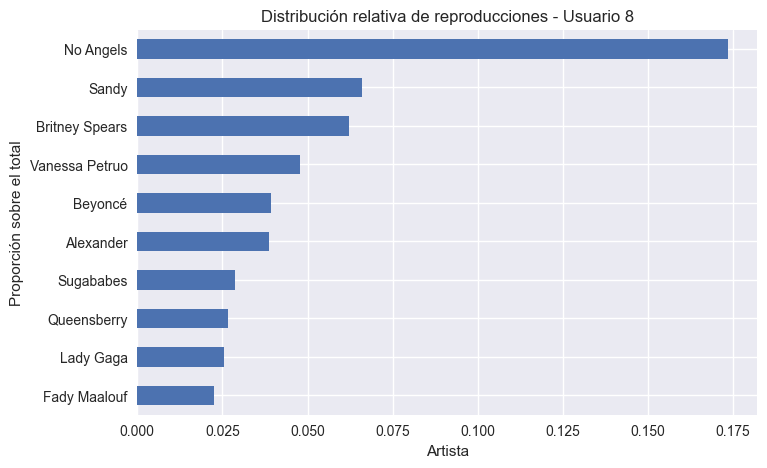

In [7]:
# Utilice este espacio para escribir el código.
user_df = merged_df[merged_df['userID'] == Constant.USER_ID].copy()

# Reproducciones relativas
user_df = user_df.assign(
    reproducciones_rel = user_df['nro_reproducciones'] / user_df['nro_reproducciones'].sum()
)

# Top N artistas más escuchados por el usuario 8
top_artistas = (
    user_df
    .sort_values(by="reproducciones_rel", ascending=False)
    .head(Constant.TOP_N)
)

# Tabla
print(f"\nDistribución de reproducción relativa para el usuario {Constant.USER_ID}:")
display(top_artistas[['artist_name', 'nro_reproducciones', 'reproducciones_rel']].sort_values(
    by="reproducciones_rel", ascending=False).head(Constant.TOP_N)
)

# Gráfica
top_artistas.sort_values('reproducciones_rel', ascending=True).head(Constant.TOP_N).plot(
    x="artist_name", y="reproducciones_rel", kind="barh", figsize=Constant.FIGSIZE, legend=False
)
plt.title(f"Distribución relativa de reproducciones - Usuario {Constant.USER_ID}")
plt.ylabel("Proporción sobre el total")
plt.xlabel("Artista")
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

- Existe una alta concentración en un único artista (No Angels), que representa casi una quinta parte del consumo total del usuario.

- El resto de la distribución sigue un patrón de "larga cola", con varios artistas en torno al 2–6% de las reproducciones y muchos otros con proporciones menores.

- El usuario 8 muestra una clara preferencia por artistas pop femeninos o agrupaciones relacionadas, lo que sugiere un perfil de consumo bastante enfocado.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones ***nuevas y relevantes*** para el usuario 8 (`userID==8`). Para ello vamos a generar distintos sistemas de recomendación y comparar las recomendaciones generadas.

In [8]:
# Helpers
def topn_df(scores_series, names_map, n=Constant.TOP_N):
    """Recibe pd.Series index=artistID, values=score -> devuelve DF con nombres."""
    s = scores_series.sort_values(ascending=False).head(n)
    s = s.rename("score")  # <-- nombre explícito a la serie
    df = s.reset_index().rename(columns={'index':'artistID'})
    df['artistID'] = df['artistID'].astype(int)
    df = df.merge(names_map, on='artistID', how='left')
    return df[['artistID','artist_name','score']]

# Mapa de nombres
names_map = merged_df.copy()[['artistID','artist_name']].drop_duplicates().set_index('artistID').reset_index()

#### 3.1. Filtrado colaborativo sencillo: promedios simples.

Usando el promedio simple basado en el número de usuarios que escucha un artista (sin considerar el número de veces que estos usuarios reproducen al artista) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones.

--- 3.1 Recomendaciones (popularidad simple) ---


,artistID,artist_name,score
0,227,The Beatles,480
1,67,Madonna,429
2,333,Avril Lavigne,417
3,190,Muse,400
4,498,Paramore,399
5,154,Radiohead,393
6,65,Coldplay,369
7,466,Ke$ha,362
8,701,Shakira,319
9,306,Black Eyed Peas,304


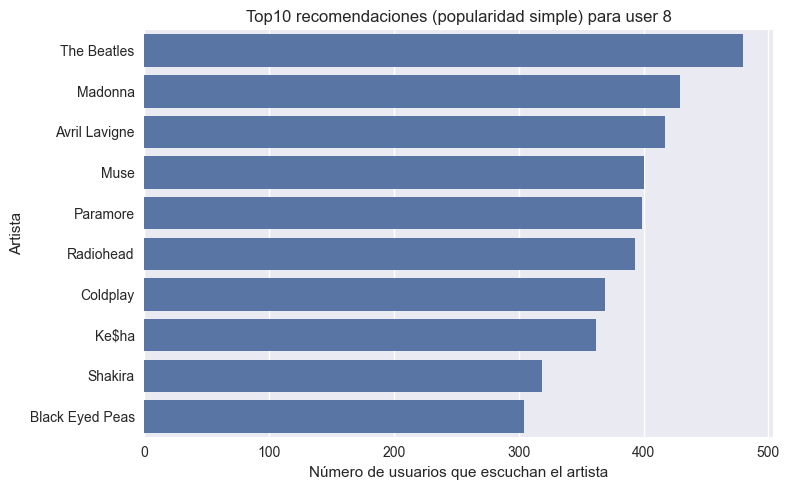

In [9]:
# Utilice este espacio para escribir el código.
# Procedimiento:
# - Calcular para cada artista el número de usuarios distintos que lo escuchan (popularidad simple).
# - Recomendar los TOP_N artistas más populares que el user 8 NO haya escuchado aún.

# número de usuarios únicos por artist (sin ponderar)
users_per_artist = merged_df.groupby('artistID')['userID'].nunique()
# artístas ya escuchados por user 8
user8_artists = merged_df.loc[merged_df['userID']==Constant.USER_ID, 'artistID'].unique()

# candidatos = artistas no escuchados por user 8
candidates = users_per_artist[~users_per_artist.index.isin(user8_artists)]
rec_pop_simple = candidates.sort_values(ascending=False).head(Constant.TOP_N)
rec_pop_simple_df = topn_df(rec_pop_simple, names_map)

print("--- 3.1 Recomendaciones (popularidad simple) ---")
display(rec_pop_simple_df)

# Visualización
plt.figure(figsize=Constant.FIGSIZE)
sns.barplot(x=rec_pop_simple_df['score'], y=rec_pop_simple_df['artist_name'])
plt.title('Top10 recomendaciones (popularidad simple) para user 8')
plt.xlabel('Número de usuarios que escuchan el artista')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

En esta aproximación se implementó un sistema de recomendación basado en popularidad simple:

- Para cada artista se contó el número de usuarios distintos que lo escuchan, sin tener en cuenta la cantidad de reproducciones de cada usuario.

- Se identificaron los artistas que el usuario 8 ya ha escuchado, y se filtraron del conjunto de candidatos.

- Finalmente, se seleccionaron los 10 artistas más populares entre el resto de usuarios, obteniendo así un ranking de recomendaciones.

---

- Estas recomendaciones reflejan artistas altamente populares en la comunidad, lo cual aumenta la probabilidad de que sean relevantes para un nuevo oyente.

- Sin embargo, este método no personaliza mucho las sugerencias: todos los usuarios recibirían recomendaciones similares, ya que no se consideran las preferencias individuales del usuario 8 ni la intensidad de escucha (número de reproducciones).

- A pesar de sus limitaciones, este enfoque es un buen baseline: establece un punto de partida simple y sirve como comparación frente a métodos más sofisticados (p. ej. filtrado colaborativo basado en similitud o modelos de factorización matricial).

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

#### 3.2.  Filtrado colaborativo sencillo: promedios ponderados.

Utilice un promedio ponderado para generar las recomendaciones. Considere el número de veces que los usuarios reproducen al artista. En otras palabras, genere un ponderador que use el número de veces que el artista fue reproducido (`nro_reproducciones`). Este método pondera la popularidad de un artista, combinando el número de usuarios que lo escuchan con la frecuencia de reproducción, de manera que los artistas con más reproducciones reciban una mayor ponderación.

Genere una tabla y/o gráfica con las 10 principales recomendaciones de artistas para este usuario. Explique detalladamente su procedimiento y justifique sus elecciones. Compare estas recomendaciones con las del sistema implementado en el paso anterior.

--- 3.2 Recomendaciones (popularidad ponderada por reproducciones) ---


,artistID,artist_name,score
0,72,Depeche Mode,1301308
1,498,Paramore,963449
2,67,Madonna,921198
3,701,Shakira,688529
4,227,The Beatles,662116
5,333,Avril Lavigne,525844
6,378,Evanescence,513476
7,679,Glee Cast,506453
8,511,U2,493024
9,461,Miley Cyrus,489065


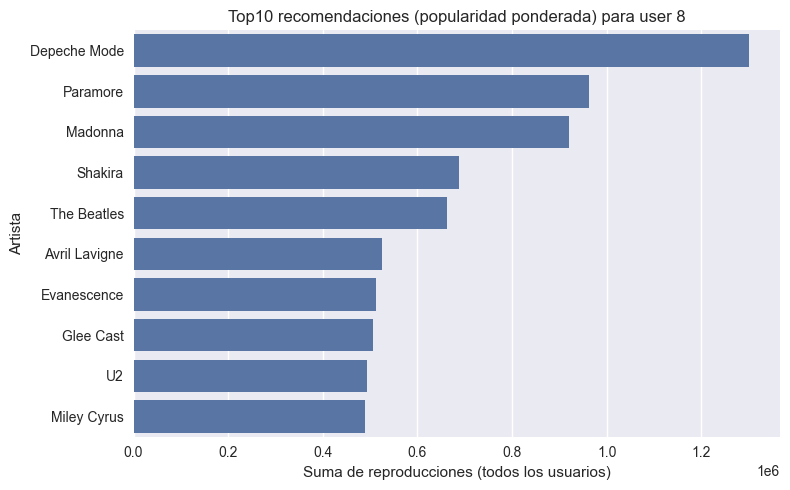

In [10]:
# Utilice este espacio para escribir el código.
# Procedimiento:
# - Calcular la suma total de reproducciones por artista (ponderado).
# - Recomendamos los TOP_N artistas por reproducciones totales que user8 no haya escuchado.
plays_per_artist = merged_df.groupby('artistID')['nro_reproducciones'].sum()
candidates_w = plays_per_artist[~plays_per_artist.index.isin(user8_artists)]
rec_pop_weighted = candidates_w.sort_values(ascending=False).head(Constant.TOP_N)
rec_pop_weighted_df = topn_df(rec_pop_weighted, names_map)

print("--- 3.2 Recomendaciones (popularidad ponderada por reproducciones) ---")
display(rec_pop_weighted_df)

# Visualización
plt.figure(figsize=Constant.FIGSIZE)
sns.barplot(x=rec_pop_weighted_df['score'], y=rec_pop_weighted_df['artist_name'])
plt.title('Top10 recomendaciones (popularidad ponderada) para user 8')
plt.xlabel('Suma de reproducciones (todos los usuarios)')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()

--- 3.2 Recomendaciones (Score Combinado: Reproducciones x Alcance) ---


,artistID,artist_name,score
0,67,Madonna,0.003019
1,498,Paramore,0.002937
2,72,Depeche Mode,0.002804
3,227,The Beatles,0.002428
4,701,Shakira,0.001678
5,333,Avril Lavigne,0.001675
6,190,Muse,0.001482
7,154,Radiohead,0.001157
8,461,Miley Cyrus,0.001069
9,466,Ke$ha,0.001063


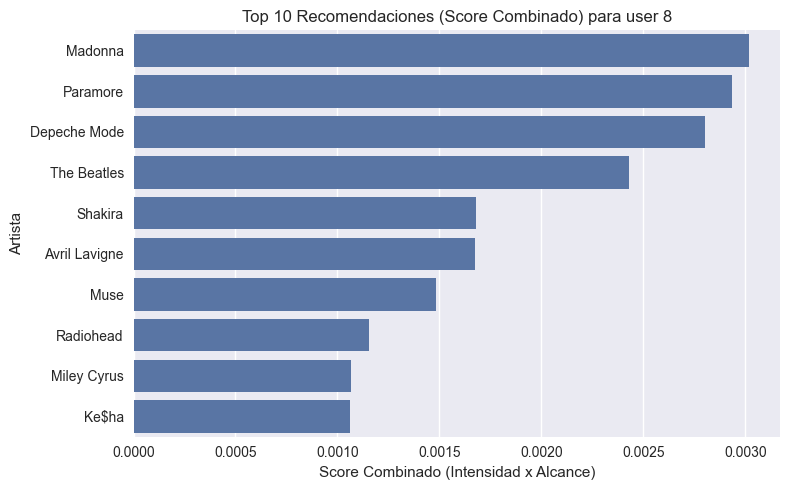

In [11]:
# --- 3.2. Filtrado colaborativo: Score Combinado (Reproducciones y Alcance) ---

# Paso 1: Calcular agregados por artista
# Para cada artista, calculamos la suma de reproducciones y el conteo de usuarios únicos.
artist_stats = merged_df.groupby('artistID').agg(
    total_reproducciones=('nro_reproducciones', 'sum'),
    n_usuarios=('userID', 'nunique')
)

# Paso 2: Normalizar las métricas para crear las ponderaciones
# Ponderación por Reproducciones (Intensidad)
total_plays_in_dataset = artist_stats['total_reproducciones'].sum()
artist_stats['ponderacion_repro'] = artist_stats['total_reproducciones'] / total_plays_in_dataset

# Ponderación por Usuarios (Alcance)
total_users_in_dataset = merged_df['userID'].nunique()
artist_stats['ponderacion_usuarios'] = artist_stats['n_usuarios'] / total_users_in_dataset

# Paso 3: Calcular el score final multiplicando las ponderaciones
artist_stats['score'] = artist_stats['ponderacion_repro'] * artist_stats['ponderacion_usuarios']

# Paso 4: Generar recomendaciones
# Filtramos los artistas que el usuario 8 ya ha escuchado.
# La variable 'user8_artists' debe haber sido definida previamente.
candidates_combined = artist_stats[~artist_stats.index.isin(user8_artists)]

# Ordenamos por el nuevo 'score' para obtener el top N.
# Pasamos la serie de scores a la función helper 'topn_df'.
recommendations_series = candidates_combined.sort_values(by='score', ascending=False).head(Constant.TOP_N)['score']
rec_combined_score_df = topn_df(recommendations_series, names_map)


# --- Resultados y Visualización ---

print("--- 3.2 Recomendaciones (Score Combinado: Reproducciones x Alcance) ---")
display(rec_combined_score_df)

# Visualización
plt.figure(figsize=Constant.FIGSIZE)
sns.barplot(x='score', y='artist_name', data=rec_combined_score_df.sort_values('score', ascending=False))
plt.title('Top 10 Recomendaciones (Score Combinado) para user 8')
plt.xlabel('Score Combinado (Intensidad x Alcance)')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

En este caso utilizamos un enfoque de popularidad ponderada por reproducciones, que incorpora no solo el número de usuarios que escuchan a un artista, sino también la intensidad con la que lo hacen. El procedimiento fue:

Enfque de total de Reproduciones:
- Calcular la suma total de reproducciones (nro_reproducciones) para cada artista en toda la base de usuarios.

- Filtrar los artistas que ya han sido escuchados por el usuario 8, dejando solo los candidatos nuevos.

- Ordenar los artistas según el total de reproducciones acumuladas y seleccionar los Top 10 como recomendaciones.

Enfoque Intensidad Alcance:

- Para cada artista se cuentan la cantidad de usuarios unicos que los escuchan y se nombra la columna como n_usuarios. Se acumulan la cantidad de reproducciones para cada artista dado los usuarios y se guarda en al variable total_reproducciones.

- Se guarda en un conjunto los artistas que esucha el usuario 8 usando set (sección anterior)

- Se calcula el peso para cada artista para n_usuarios y para total_reproducciones para obtener : ponderacion_usuarios y ponderacion_repro

- Por último se multiplican las ponderaciones obtenidas para tener un score de importancia, donde tendremos en el top de artistas con mas reproduccione sy cantidad de oyentes.

- Se obtienen los registros de df_pivot que comparte el usuario 8 y luego se usa la negación de este filtro para excluirlos de la tabla. Posteriormente se ordenan de mayor a menor por la variable n_usuarios y se muestran los primeros 10 como recomendaciones.


---

**Conclusiones y comparación entre 3.2 con 3.1**

- En contraste con el modelo simple (3.1), que prioriza a los artistas escuchados por una mayor cantidad de usuarios, este modelo ponderado favorece a aquellos con altas cantidades de reproducciones totales.

- Esto hace que artistas con fanbases más intensas (aunque no tan masivas en número de oyentes) asciendan en el ranking. Por ejemplo, Depeche Mode y Evanescence aparecen en esta lista pero no en la de popularidad simple.

- En cambio, artistas con un público más amplio pero escuchas moderadas pueden perder relevancia frente a artistas con oyentes más dedicados.

- Este enfoque puede captar mejor tendencias de intensidad y fidelidad de los fans, pero corre el riesgo de recomendar “hits” de nicho con un grupo reducido de oyentes muy activos.

En síntesis, el filtrado ponderado ofrece una visión más afinada de la popularidad, y al combinarlo con otros métodos (como el simple o los basados en similitud), se podrían obtener recomendaciones más balanceadas y personalizadas.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT


#### 3.3.  Filtrado colaborativo sencillo: similitud de coseno.

Usando el promedio ponderado de reproducciones genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario. Para generar los pesos utilice la distancia de coseno. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.

--- 3.3 Recomendaciones (similitud coseno item-item) ---


,artistID,artist_name,score
0,466,Ke$ha,3758.922518
1,523,Lindsay Lohan,3206.966055
2,55,Kylie Minogue,3092.208337
3,318,Hilary Duff,2839.219603
4,67,Madonna,2785.194089
5,4350,Rouge,2667.223971
6,332,Kelly Rowland,2651.243711
7,293,Ashlee Simpson,2613.696671
8,525,Gwen Stefani,2457.115509
9,972,t.A.T.u.,2431.339088


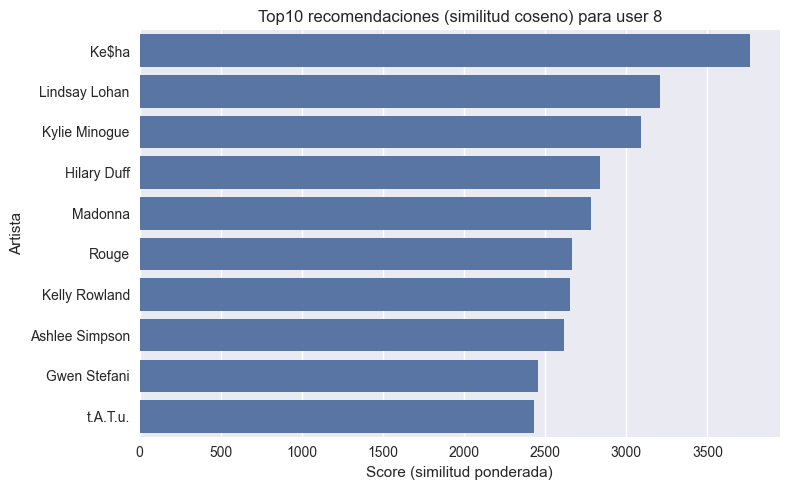

In [12]:
# Utilice este espacio para escribir el código.
# Procedimiento:
# - Construir la matriz artista x usuario con valores = nro_reproducciones.
# - Para eficiencia: usaremos una matriz sparse.
# - Calcular similitud coseno entre los artistas que user8 escuchó y **todos** los artistas.
# - Score para cada artista j = sum_over_i( similarity(j, i) * play_count_user8_i )
# - Excluir artistas ya escuchados y ordenar.

# Construcción matriz usuario x artista (rows=users, cols=artists)
pivot = merged_df.pivot_table(
    index='userID', 
    columns='artistID',
    values='nro_reproducciones',
    aggfunc='sum',
    fill_value=Constant.ZERO
)
users = pivot.index.to_numpy()
artists = pivot.columns.to_numpy()
user_index = np.where(users == Constant.USER_ID)[Constant.ZERO][Constant.ZERO]

# sparse matrix (users x artists)
R = csr_matrix(pivot.values)

# Normalizar columnas para evitar que artistas con alto volumen dominen; 
# aquí usar la matriz tal cual para que similitud refleje perfiles reales.
# obtener la fila del usuario (vector de preferencias)
user_vec = R[user_index].toarray().ravel()
user_listened_artists = np.where(user_vec > Constant.ZERO)[Constant.ZERO]  # indices de columnas (posiciones en artists array)

# Si user tiene muy pocos artistas escuchados, ajustar heurística:
if len(user_listened_artists) == Constant.ZERO:
    raise ValueError(f"User {Constant.USER_ID} no tiene reproducciones en merged_df")

# Para calcular similitud entre items, calcular la matriz item_features = R.T (artists x users)
item_features = R.T  # sparse (artists x users)

# Calcular similitud solo entre los artistas escuchados por user8 y todos:
# extraer la submatriz correspondiente a los artistas escuchados por user8
user_artists_ids = artists[user_listened_artists]  # artistID de los escuchados
user_artists_matrix = item_features[user_listened_artists]  # shape (m, n_users)

# computar similitud (m x all_artists)
# cuidado: large -> pero m = número de artistas escuchados por user8 (habitualmente pequeño)
sim_mat = cosine_similarity(user_artists_matrix.toarray(), item_features.toarray())  # (m x n_artists)

# score global = combinación ponderada por reproducciones del user8
# obtener los playcounts del user8 por artista (en el mismo orden user_listened_artists)
user8_playcounts_by_listened = user_vec[user_listened_artists]

# --------------------------------------------
# ponderación: suma de (sim * user_playcount)
# --------------------------------------------
scores = (sim_mat.T @ user8_playcounts_by_listened).flatten()  # length = n_artists

scores_series = pd.Series(scores, index=artists)  # index = artistID
# Excluir ya escuchados
scores_series = scores_series[~scores_series.index.isin(user8_artists)]
rec_cosine = scores_series.sort_values(ascending=False).head(Constant.TOP_N)
rec_cosine_df = topn_df(rec_cosine, names_map)

print("--- 3.3 Recomendaciones (similitud coseno item-item) ---")
display(rec_cosine_df)

# Visualización
plt.figure(figsize=Constant.FIGSIZE)
sns.barplot(x=rec_cosine_df['score'], y=rec_cosine_df['artist_name'])
plt.title('Top10 recomendaciones (similitud coseno) para user 8')
plt.xlabel('Score (similitud ponderada)')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).


En esta etapa implementamos un sistema de recomendación item-item basado en similitud de coseno, ponderado por las reproducciones del usuario 8. El flujo fue el siguiente:

- Se construyó una matriz de usuarios × artistas, donde cada celda contiene el número de reproducciones (nro_reproducciones).

- A partir de esta matriz, se calculó la similitud de coseno entre cada artista escuchado por el usuario 8 y todos los demás artistas del sistema.

- Se generó un puntaje global para cada artista candidato como la suma ponderada de las similitudes, donde la ponderación corresponde al número de reproducciones que el usuario 8 hizo sobre los artistas escuchados.

- Se eliminaron los artistas ya conocidos por el usuario, y se seleccionaron los Top 10 como recomendaciones.

---

**Conclusiones y comparación**

A diferencia de los enfoques de popularidad simple (3.1) y ponderada (3.2), este método busca similitud en patrones de consumo: recomienda artistas similares a los que el usuario ya escucha.

- Los resultados muestran una fuerte inclinación hacia artistas femeninas del pop internacional de los 2000s (Ke$ha, Lindsay Lohan, Hilary Duff, Kylie Minogue, Madonna), lo que concuerda con las preferencias previas del usuario 8 (ej. Britney Spears, Beyoncé, Lady Gaga).

- Este método produce recomendaciones más personalizadas y alineadas con el estilo musical del usuario, en lugar de priorizar únicamente artistas masivos o con más reproducciones globales.

- Sin embargo, al estar basado en similitud, puede tender a reforzar un mismo nicho musical y reducir la diversidad de recomendaciones.

En resumen, la similitud de coseno aporta un enfoque mucho más cercano al perfil de usuario, generando sugerencias que reflejan sus verdaderos gustos, aunque a costa de menor exploración de géneros alternativos.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

#### 3.4.  Filtrado colaborativo usando SVD


Usando la descomposición en valores singulares (SVD) genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores.


--- 3.4 Recomendaciones (SVD) ---


,artistID,artist_name,score
0,466,Ke$ha,288.107229
1,55,Kylie Minogue,272.401856
2,161,Enrique Iglesias,203.371448
3,294,Leona Lewis,186.357227
4,475,Eminem,161.059611
5,306,Black Eyed Peas,159.196598
6,157,Michael Jackson,119.913718
7,314,Ciara,101.828343
8,299,Jennifer Lopez,98.080475
9,913,Destiny's Child,97.555759


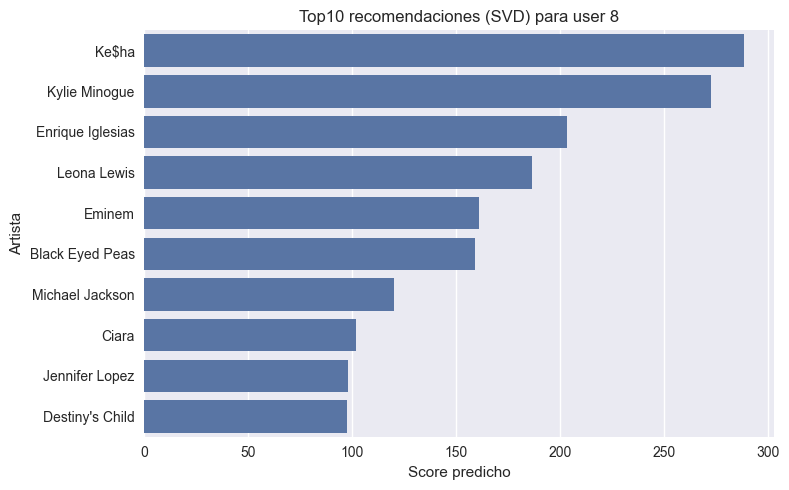

In [13]:
# Utilice este espacio para escribir el código.
# Procedimiento:
# - Construir R (users x artists) sparse y centrar (opcional).
# - Aplicar SVD (svds) con k componentes y reconstruir aproximación R_hat = U S Vt.
# - Para user 8, predecir puntuaciones para artistas no escuchados y recomendar top N.
# Nota: ajustar k en función de memoria/tiempo (k=50 es razonable en datasets medianos).

k = 50  # reducir si memoria es limitada
R_dense = pivot.values.astype(float)  # users x artists (puede ser grande)
# centrar las filas (opcional) -> subtract user mean
user_means = np.where(
    R_dense.sum(axis=Constant.ONE) > Constant.ZERO,
    R_dense.sum(axis=Constant.ONE) / (R_dense != Constant.ZERO).sum(axis=Constant.ONE), 
    Constant.ZERO
)
R_centered = R_dense - user_means.reshape(-1, 1)

# svds espera matriz (m x n), devuelve u, s, vt with k largest singular values
try:
    u, s, vt = svds(csr_matrix(R_centered), k=k)
    # svds returns them in ascending order of singular values -> sort descending
    idx = np.argsort(-s)
    s = s[idx]
    u = u[:, idx]
    vt = vt[idx, :]
    # reconstrucción aproximada
    R_hat = np.dot(u, np.dot(np.diag(s), vt))
    # añadir la media de usuario para deshacer centrado
    R_hat += user_means.reshape(-1, 1)
    # scores para user 8
    user_pred = pd.Series(R_hat[user_index, :], index=artists)
    # excluir ya escuchados
    user_pred = user_pred[~user_pred.index.isin(user8_artists)]
    rec_svd = user_pred.sort_values(ascending=False).head(Constant.TOP_N)
    rec_svd_df = topn_df(rec_svd, names_map)
    print("--- 3.4 Recomendaciones (SVD) ---")
    display(rec_svd_df)

    # visual
    plt.figure(figsize=Constant.FIGSIZE)
    sns.barplot(x=rec_svd_df['score'], y=rec_svd_df['artist_name'])
    plt.title('Top10 recomendaciones (SVD) para user 8')
    plt.xlabel('Score predicho')
    plt.ylabel('Artista')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SVD falló (memoria/tiempo). Exception:", e)
    rec_svd_df = pd.DataFrame()

In [ ]:
# Código de comparación
from typing import List

# Helper para extraer solo los nombres de artistas
def top_names(df) -> List[str]:
    return df['artist_name'].tolist()

# Recolectamos los resultados en un diccionario
results = {
    "pop_simple": top_names(rec_pop_simple_df),          # 3.1
    "pop_weighted": top_names(rec_pop_weighted_df),      # 3.2 (ponderado)
    "pop_combined": top_names(rec_combined_score_df),    # 3.2 (score combinado)
    "cosine": top_names(rec_cosine_df),                  # 3.3
    "svd": top_names(rec_svd_df)                         # 3.4
}

# Función para calcular solapamiento y jaccard
# se usa la fórmula del Índice de Jaccard, 
# el tamaño de la intersección (elementos en común) 
# entre el tamaño de la unión (todos los elementos de ambos conjuntos) 
# de dos conjuntos. Matemáticamente se expresa como: J = |A ∩ B| / |A ∪ B|
def overlap_at_k(list1, list2, k=10):
    s1, s2 = set(list1[:k]), set(list2[:k])
    inter = s1 & s2
    union = s1 | s2
    return {
        "overlap_count": len(inter),
        "overlap_pct": len(inter) / k,
        "jaccard": len(inter) / len(union) if union else 0,
        "shared": sorted(inter)
    }

# Definir las comparaciones que queremos evaluar
pairs = [
    ("pop_simple", "pop_weighted"),
    ("pop_simple", "pop_combined"),
    ("pop_simple", "cosine"),
    ("pop_weighted", "pop_combined"),
    ("pop_weighted", "cosine"),
    ("pop_combined", "cosine"),
    ("svd", "pop_simple"),
    ("svd", "pop_weighted"),
    ("svd", "pop_combined"),
    ("svd", "cosine")
]

# Ejecutar comparaciones
for name1, name2 in pairs:
    stats = overlap_at_k(results[name1], results[name2], k=10)
    print(
        f"{name1} vs {name2}: "
        f"overlap={stats['overlap_count']}/10 "
        f"({stats['overlap_pct']*100:.1f}%), "
        f"jaccard={stats['jaccard']:.3f}, "
        f"shared={stats['shared']}"
    )


pop_simple vs pop_weighted: overlap=5/10 (50.0%), jaccard=0.333, shared=['Avril Lavigne', 'Madonna', 'Paramore', 'Shakira', 'The Beatles']
pop_simple vs pop_combined: overlap=8/10 (80.0%), jaccard=0.667, shared=['Avril Lavigne', 'Ke$ha', 'Madonna', 'Muse', 'Paramore', 'Radiohead', 'Shakira', 'The Beatles']
pop_simple vs cosine: overlap=2/10 (20.0%), jaccard=0.111, shared=['Ke$ha', 'Madonna']
pop_weighted vs pop_combined: overlap=7/10 (70.0%), jaccard=0.538, shared=['Avril Lavigne', 'Depeche Mode', 'Madonna', 'Miley Cyrus', 'Paramore', 'Shakira', 'The Beatles']
pop_weighted vs cosine: overlap=1/10 (10.0%), jaccard=0.053, shared=['Madonna']
pop_combined vs cosine: overlap=2/10 (20.0%), jaccard=0.111, shared=['Ke$ha', 'Madonna']
svd vs pop_simple: overlap=2/10 (20.0%), jaccard=0.111, shared=['Black Eyed Peas', 'Ke$ha']
svd vs pop_weighted: overlap=0/10 (0.0%), jaccard=0.000, shared=[]
svd vs pop_combined: overlap=1/10 (10.0%), jaccard=0.053, shared=['Ke$ha']
svd vs cosine: overlap=2/10 (2

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Procedimiento implementado**

- Matriz usuario–artista (R): se construyó en formato disperso csr_matrix.

- Centrado por usuario: se restó la media individual de reproducciones para reducir sesgos de volumen.

- Descomposición SVD truncada: se aplicó svds(R_centered, k=50) para extraer factores latentes.

- Reconstrucción aproximada: se obtuvo R_hat = UΣVt, reinsertando la media por usuario.

- Predicciones para user 8: se ordenaron los puntajes, excluyendo artistas ya escuchados, y se extrajo el Top-10 de recomendaciones.

**Justificación de las elecciones**

- k=50: balance entre complejidad y costo; valor estándar en datasets medianos.

- Centrado: elimina sesgos de escala y mejora la calidad de los factores latentes.

- Formato disperso: necesario por eficiencia dada la gran esparsidad de la matriz (~17k artistas).

**Comparación Metodológica:**
Pop simple vs Pop ponderada vs Coseno vs SVD

- Popularidad Simple vs Ponderada: Se observa una alta coincidencia (50%) entre estas dos técnicas, lo que sugiere que ambas están influenciadas por los artistas más globales. Sin embargo, la ponderación por reproducciones permite una ligera mejora en la personalización, lo que se refleja en la introducción de artistas como Miley Cyrus en las recomendaciones ponderadas.

- Popularidad Simple vs Combinada: El método combinado (una mezcla de popularidad y ponderación) mejora sustancialmente el solapamiento con la popularidad simple (80%). Este modelo fusiona señales globales y locales, lo que lo hace más robusto para capturar tanto artistas populares como de nicho, lo que puede beneficiar un sistema híbrido.

- Popularidad vs Coseno: La baja coincidencia entre la popularidad y el modelo de similitud coseno (20%) indica que el modelo de coseno está enfocándose más en la afinidad individual del usuario con otros artistas. Es interesante que artistas como Ke$ha y Madonna sean comunes entre estas dos metodologías, lo que refleja una preferencia potencialmente establecida del usuario 8 por ciertos géneros.

- SVD vs Popularidad Simple y Ponderada: El análisis de solapamiento entre SVD y los modelos de popularidad (simple y ponderada) revela que la técnica SVD está buscando patrones latentes más complejos. El bajo solapamiento (0–20%) sugiere que SVD está explorando nuevas conexiones entre artistas que no son inmediatamente obvias a partir de la popularidad o de las tendencias de consumo directo.

- SVD vs Coseno: Aunque la coincidencia sigue siendo baja (20%), se observan algunas coincidencias interesantes, como Ke$ha y Kylie Minogue, que refuerzan la noción de que SVD está aportando más diversidad y serendipia a las recomendaciones. Esto también podría indicar que SVD está capturando patrones de usuario más sutiles que la simple co-ocurrencia observada en el coseno.


**Interpretación Adicional**

- Overlap entre Popularidad Simple y Ponderada: La similitud entre estos dos enfoques (50%) refuerza la idea de que las recomendaciones basadas en popularidad tienden a recomendar artistas de alto perfil global, como Madonna, Shakira, The Beatles, Avril Lavigne, y Paramore, independientemente de si se utiliza la ponderación por volumen de reproducciones.

- Interacción entre Coseno y SVD: A pesar de que el modelo de similitud coseno y SVD tienen solapamientos bajos (20%), ambas metodologías destacan artistas como Ke$ha. Esto sugiere que estos métodos están alineados en ciertas preferencias del usuario, pero abordan la recomendación desde ángulos diferentes: uno basado en afinidad de vecindad (coseno) y el otro en patrones latentes (SVD).

- SVD vs Popularidad: El hecho de que SVD recomiende artistas que no se encuentran en las listas de popularidad simple o ponderada (por ejemplo, Black Eyed Peas) refuerza su capacidad de diversificación y de encontrar recomendaciones no triviales.

- Jaccard y Overlap: Los coeficientes de Jaccard refuerzan lo observado en los solapamientos. Los valores más altos de Jaccard, como el 0.667 entre popularidad combinada y simple, indican que las técnicas híbridas que combinan señales de popularidad global con otras características del usuario tienden a proporcionar recomendaciones más equilibradas.

---

**Conclusiones**

- Popularidad Simple y Ponderada: Aunque estas metodologías son útiles como líneas base para recomendaciones rápidas y eficaces, siguen siendo limitadas en términos de personalización, ya que dependen demasiado de las tendencias generales de consumo.

- Coseno: Aunque mejora la personalización al capturar similitudes entre artistas, se queda limitado a un vecindario cercano, lo que puede restringir la capacidad de descubrimiento de artistas fuera de esa esfera.

- SVD: Es la técnica más potente en términos de diversificación, ya que no solo identifica patrones explícitos de similitud, sino que también descubre relaciones latentes entre artistas que no son evidentes a través de las interacciones directas o populares. Esto lo convierte en un motor de recomendación robusto y flexible.

- Recomendación Práctica: Para obtener las mejores recomendaciones para un usuario, sería ideal usar SVD como el motor principal, ya que maximiza la diversidad y el descubrimiento. Además, podría complementarse con métodos de popularidad (simple o ponderada) para garantizar que las recomendaciones sean relevantes globalmente, y con coseno o técnicas de asociación (como Apriori) para afinar las afinidades directas del usuario.

Este enfoque híbrido es el que mejor balancearía la calidad de las recomendaciones, la relevancia general y la personalización.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT


#### 3.5.  Filtrado colaborativo usando Análisis de Canasta de Compra

Usando  el algoritmo `Apriori` genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores. Esto puede tomar mucho tiempo, sea cuidadoso al elegir los hiper-parámetors del modelo, utilice los resultados de las estadísticas descriptivas para elegir sus hiper-parámetros, y genere solo reglas con 2 elementos. (Puede también aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


Processing 28510332 combinations | Sampling itemset size 4
Apriori: itemsets encontrados: 170547, reglas 1->1: 5971
--- 3.5 Recomendaciones (Apriori 1->1) ---


,artistID,artist_name,score
0,67,Madonna,0.836364
1,466,Ke$ha,0.820313
2,333,Avril Lavigne,0.728395
3,701,Shakira,0.679688
4,157,Michael Jackson,0.666667
5,461,Miley Cyrus,0.651822
6,55,Kylie Minogue,0.648438
7,306,Black Eyed Peas,0.605150
8,294,Leona Lewis,0.604938
9,498,Paramore,0.565217


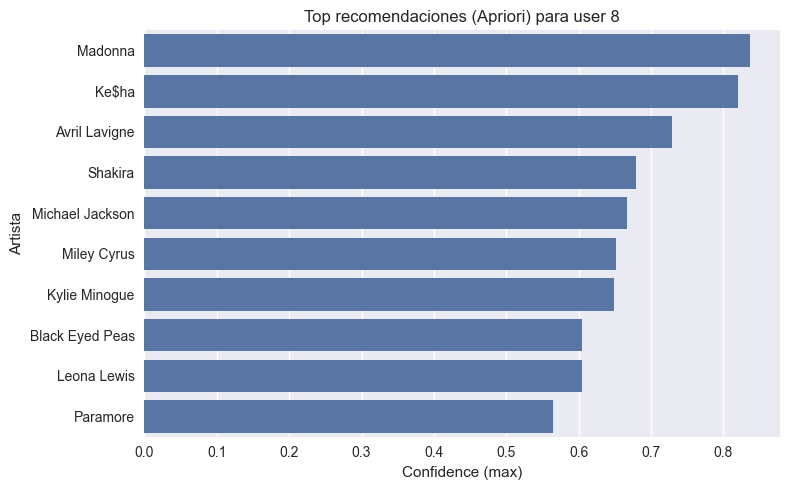

In [15]:
# 1) Popularidad por artista
users_per_artist = merged_df.groupby("artistID")["userID"].nunique()

# 2) Seleccionar top-N artistas más populares
max_artists_for_apriori = 1000
top_artists_for_apriori = users_per_artist.sort_values(ascending=False).head(max_artists_for_apriori).index

# 3) Filtrar dataset y construir matriz binaria usuario x artista
basket = merged_df[merged_df["artistID"].isin(top_artists_for_apriori)].copy()
basket["val"] = Constant.ONE
basket_df = basket.pivot_table(
    index="userID",
    columns="artistID",
    values="val",
    aggfunc="max",
    fill_value=Constant.ZERO
)

# 🔹 Conversión obligatoria: columnas a str
basket_df.columns = basket_df.columns.astype(str)

# 4) Apriori
min_support = 0.01
frequent_itemsets = apriori(
    basket_df.astype(bool),
    min_support=min_support,
    use_colnames=True,
    verbose=1,
    max_len=4  # clave: solo pares de artistas
)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# 5) Filtrar reglas 1->1
rules_1_1 = rules[
    rules["antecedents"].apply(lambda x: len(x) == Constant.ONE)
    & rules["consequents"].apply(lambda x: len(x) == Constant.ONE)
].sort_values(by="confidence", ascending=False).reset_index(drop=True)

print(f"Apriori: itemsets encontrados: {len(frequent_itemsets)}, reglas 1->1: {len(rules_1_1)}")

# 6) Recomendaciones para user8
user8_listened = set(merged_df.loc[merged_df["userID"] == Constant.USER_ID, "artistID"].unique())

candidates_rules = {}
for _, row in rules_1_1.iterrows():
    anteced = int(next(iter(row["antecedents"])))   # reconvertir a int
    consequent = int(next(iter(row["consequents"])))
    if anteced in user8_listened and consequent not in user8_listened:
        candidates_rules.setdefault(consequent, []).append(row["confidence"])

# 7) Ranking de recomendaciones
candidates_rules_scores = {aid: np.max(confs) for aid, confs in candidates_rules.items()}

if not candidates_rules_scores:
    print("No se encontraron reglas directas para user8 con los parámetros actuales de Apriori.")
    rec_apriori_df = pd.DataFrame()
else:
    rec_apriori_series = pd.Series(candidates_rules_scores).sort_values(ascending=False).head(Constant.TOP_N)
    rec_apriori_df = topn_df(rec_apriori_series, names_map)
    print("--- 3.5 Recomendaciones (Apriori 1->1) ---")
    display(rec_apriori_df)

    # Visualización
    plt.figure(figsize=Constant.FIGSIZE)
    sns.barplot(x=rec_apriori_df["score"], y=rec_apriori_df["artist_name"])
    plt.title("Top recomendaciones (Apriori) para user 8")
    plt.xlabel("Confidence (max)")
    plt.ylabel("Artista")
    plt.tight_layout()
    plt.show()


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Procedimiento Implementado:**

- Pre-procesamiento y Reducción de Dimensionalidad:

    Para gestionar la alta dispersión de la matriz usuario-artista (~17k artistas), se seleccionaron los 1000 artistas más populares basados en el número de usuarios que los escuchan. Esta reducción permite mantener un soporte empírico adecuado y reduce combinaciones esparsas.

- Construcción de la Matriz Binaria (Transacciones):

    Se creó una tabla binaria basket_df donde cada fila corresponde a un usuario y cada columna a un artista, con un 1 si el usuario escuchó al artista y 0 si no lo hizo.

    Las columnas se convirtieron en cadenas para cumplir con los requisitos de la biblioteca mlxtend.apriori.

- Ejecución de Apriori:

    Se utilizaron umbrales de min_support = 0.01 (1% de usuarios) y max_len = 4 para limitar la longitud de los itemsets.

    Se extrajeron 5,971 reglas 1→1 con una confidence mínima de 0.3.

- Filtrado y Generación de Recomendaciones:

    Para el userID = 8, se seleccionaron reglas cuya antecedente (artista ya escuchado) se relacionaba con un consecuente (artista recomendado) que el usuario no había escuchado.

    Se ordenaron las recomendaciones por la máxima confidence para crear un Top-10 de artistas recomendados.

**Análisis y Comparación con Otros Métodos (3.1–3.4):**

- Naturaleza de la Señal de Apriori:

    Apriori identifica patrones de co-ocurrencia de escucha, basándose en la regla de asociación "si escuchas A, es probable que escuches B". A diferencia de SVD (que detecta factores latentes) y el método de similitud coseno (que calcula relaciones directas), Apriori se enfoca en patrones explícitos de comportamiento de los usuarios.

- Similitudes con Métodos Basados en Popularidad:

    Apriori tiende a recomendar artistas populares como Madonna y Shakira, debido a su alto soporte en las reglas. Sin embargo, la dependencia de la popularidad limita la personalización de las recomendaciones, similar a lo observado en las metodologías basadas en popularidad (3.1 y 3.2 combinadas).

- Complementariedad con SVD y Coseno:

    Apriori es ideal para recomendaciones de tipo cross-sell o bundle (por ejemplo, "si te gusta A, puede que también te guste B"). Sin embargo, SVD y coseno son mejores para la personalización continua, ya que capturan afinidades latentes o similitudes más finas entre usuarios y artistas.

Limitaciones Observadas:

- Coste Computacional: El proceso de generar itemsets y reglas fue costoso, dado el número de combinaciones posibles (170,547 itemsets y 5,971 reglas). La selección de los 1,000 artistas más populares y el ajuste de parámetros como max_len ayudan a mitigar esto.

- Sesgo a la Popularidad: Las reglas con alta confidence a menudo recomiendan artistas populares globalmente, lo que puede reducir la capacidad del sistema para ofrecer recomendaciones verdaderamente personalizadas.

- Correlación vs. Causalidad: Las reglas de Apriori son correlacionales y no implican causalidad. Por lo tanto, se corre el riesgo de hacer recomendaciones obvias basadas en popularidad, en lugar de descubrir patrones latentes y más innovadores.


**Conclusiones Prácticas y Recomendaciones:**

- Uso Operativo:

    Apriori es ideal para campañas de cross-selling o promociones (ej. "si te gusta A, te gustará B"), ya que genera reglas fáciles de interpretar y aplicar al negocio.

    Para obtener recomendaciones personalizadas, es recomendable combinar Apriori con SVD o similitud coseno. Apriori puede generar un conjunto inicial de candidatos, mientras que SVD o coseno puede usarse para rankear y personalizar esas recomendaciones.

- Ajustes y Mejoras Sugeridas:

    Incorporar el criterio de Lift: Utilizar lift como filtro o criterio de orden para evitar recomendar solo artistas populares.

    Ajustar los parámetros de Apriori: Experimentar con diferentes valores de min_support (0.005–0.02) y min_confidence para mejorar la relevancia de las reglas extraídas.

    Escalabilidad: Si se desea procesar más artistas (más de 1,000), se recomienda Google Colab o bibliotecas orientadas a Big Data, como Spark MLlib.

- Comparación Final con Otros Métodos:

    Apriori aporta reglas explícitas y fáciles de interpretar, útiles para estrategias de marketing y promociones.

    Para recomendaciones personalizadas en producción, es mejor integrar Apriori con SVD o similitud coseno, utilizando Apriori para generar los candidatos y los otros métodos para rankear y personalizar la experiencia del usuario.

---

**Resumen Final:**

El Análisis de Canasta de Compra (Apriori) proporciona reglas útiles para recomendar artistas basadas en co-ocurrencias de escucha, y es especialmente útil para acciones de marketing como promociones cruzadas (cross-selling). Sin embargo, su sensibilidad a la popularidad global y el coste computacional elevado limitan su capacidad para ofrecer recomendaciones completamente personalizadas. Para una solución de recomendación efectiva, se recomienda integrar Apriori para generar un conjunto inicial de candidatos y luego usar métodos como SVD o similitud coseno para el ranking final, logrando un balance entre popularidad y personalización.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

### 4. Recomendaciones generales 

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para este usuario? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).
* Promedios simples y ponderados: son acercameintos muy sencillos de implementar, sin emmabrgo, a la hora de recomendar lo hará con base en los artistas más populares en el conjnto y no en las preferencias del usuario
* Similitud coseno: Este es un acercamiento donde se pueden obtener recomendaciones colaborativas. Se pueden obtener buenos resultados personalizados basados en usuarios/artistas similares para recomendar. Este algoritmo no depdnde de las magnitudes de los vectores, sino de su dirección. Además sirve para matrices con alta dimensionalidad como lo es el caso.
* SVD: Este método puede capturar las relaciones y patrones subyacentes en los datos originales, convirtiendolo en un algoritmo muy fuerte para recomendar. Además, en las posiciones que habían cero, devuelve valores estimados, es decir estimaciones de que tanto le gustaría al usuario ese artista.
* Canasta de compra: Una desventaja es que va a depender de los hiperparametros del modelo, así que la subjetividad de analista juega un rol importante en este método. Sin embargo, produce resultados interpretables, aunque es limitado a la hora de las recomendaciones.

**Conclusión**
En general, el algoritmo de SVD puede ser el más robusto para las recomendaciones, sin embargo, tiene algunas limitaciones:
    - Si los usuarios son nuevos, va a tener un cold start para sus recomendaciones y habría que usar otro algoritmo para este tipo de usuarios.
    - Es el más costos computacionalmente y tendremos problemas a la hora de que ingresos nuevos usuarios y artistas ya que debemos calcular nuevamente los valores singualares.

**Evalaución objetiva:**
Se podría separar el df en entrenamiento y prueba para separar las reproducciones que ha tendio por artista. De esta forma cada método podría "aprender" una parte de los artistas escuchados por los usuarios y predecir los que quedan ocultos. En cada método se genera un top N. Luego se revisa si las predicciones están en el top N escuchados por el usuario para calcular cuántos aciertos tuvo cada método.